In [1]:
!pip install -q xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import pickle, re
from transformers import pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [4]:
df = pd.read_csv('Corona_NLP_test (1).csv')

In [5]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB


In [7]:
df.dtypes

,0
UserName,int64
ScreenName,int64
Location,object
TweetAt,object
OriginalTweet,object
Sentiment,object


In [8]:
df.columns

Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')

In [9]:
df.describe(include="all")

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
count,3798.000000,3798.000000,2964,3798,3798,3798
unique,NaN,NaN,1717,15,3798,5
top,NaN,NaN,United States,13-03-2020,I and @ForestandPaper members are committed to...,Negative
freq,NaN,NaN,75,1233,1,1041
mean,1899.500000,46851.500000,NaN,NaN,NaN,NaN
std,1096.532489,1096.532489,NaN,NaN,NaN,NaN
min,1.000000,44953.000000,NaN,NaN,NaN,NaN
25%,950.250000,45902.250000,NaN,NaN,NaN,NaN
50%,1899.500000,46851.500000,NaN,NaN,NaN,NaN
75%,2848.750000,47800.750000,NaN,NaN,NaN,NaN


In [10]:
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,834
TweetAt,0
OriginalTweet,0
Sentiment,0


In [11]:
df["Location"]=df["Location"].fillna("Unknown")

In [12]:
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,0
TweetAt,0
OriginalTweet,0
Sentiment,0


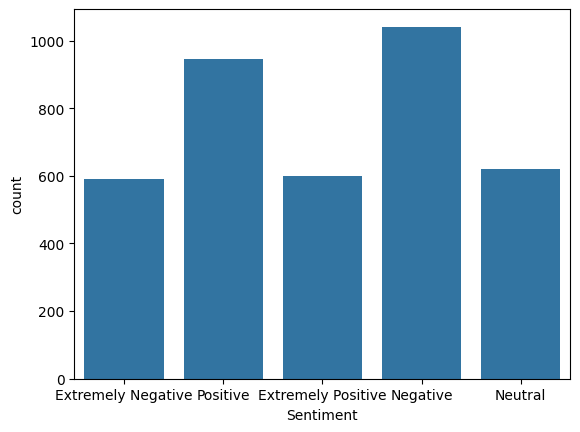

In [13]:
sns.countplot(x="Sentiment", data=df)
plt.show()

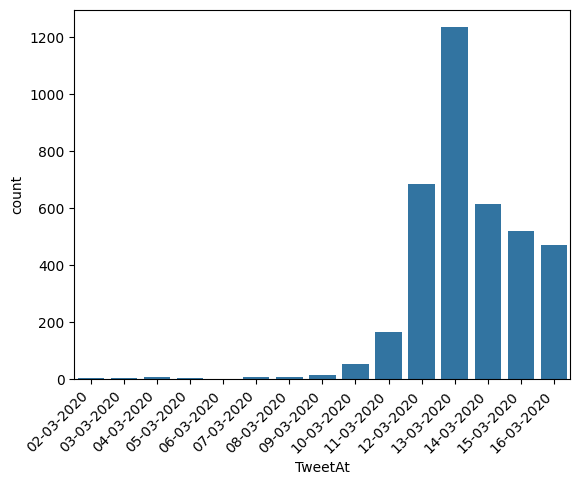

In [14]:
sns.countplot(x="TweetAt", data=df)
plt.xticks(rotation=45, ha="right")
plt.show()

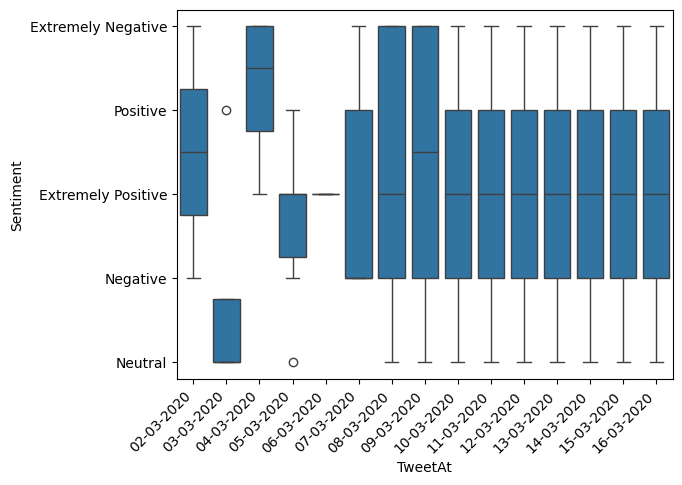

In [15]:
sns.boxplot(x="TweetAt", y="Sentiment", data=df)
plt.xticks(rotation=45, ha="right")
plt.show()

In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [17]:
df["clean_sentiment"]=df["Sentiment"].apply(clean_text)

In [18]:
X=df.drop(columns=["clean_sentiment"])
y=df["clean_sentiment"]

In [19]:
le=LabelEncoder()
y1=pd.DataFrame(le.fit_transform(y), columns=["Sentiment"], index=y.index)

In [20]:
y2=y1["Sentiment"]

In [21]:
X=pd.get_dummies(X, drop_first=True, dtype='int')

In [22]:
X.shape

(3798, 5534)

In [23]:
y2.shape

(3798,)

In [24]:
X_train, X_test, y_train, y_test= train_test_split(X, y2, test_size=0.2, random_state=42)

In [25]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [26]:
X_train.shape

(3038, 5534)

In [27]:
X_test.shape

(760, 5534)

In [28]:
y_test.shape

(760,)

In [29]:
y_train.shape

(3038,)

In [30]:
def sentiment_analysis(X_train, X_test, y_train, y_test):
    models={
        "Logistic Regression": LogisticRegression(multi_class="multinomial", max_iter=1000, random_state=42),
        "XGBoost Classifier": XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", random_state=42)
    }
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print("Classification Report:\n", classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Accuracy Score:", accuracy_score(y_test, y_pred))

In [32]:
print(sentiment_analysis(X_train, X_test, y_train, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85       115
           1       1.00      0.98      0.99       130
           2       0.95      1.00      0.97       212
           3       0.95      0.97      0.96       118
           4       0.97      0.98      0.98       185

    accuracy                           0.96       760
   macro avg       0.95      0.95      0.95       760
weighted avg       0.96      0.96      0.96       760

Confusion Matrix:
 [[ 92   0  11   6   6]
 [  3 127   0   0   0]
 [  1   0 211   0   0]
 [  3   0   0 115   0]
 [  3   0   0   0 182]]
Accuracy Score: 0.9565789473684211
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       115
           1       1.00      1.00      1.00       130
           2       1.00      1.00      1.00       212
           3       1.00      1.00      1.00       118
           4       1.0